Trying to reproduce phase diagrams from: 

- [Quantum correlations, entanglement spectrum and coherence of two-particle reduced density matrix in the Extended Hubbard Model](https://arxiv.org/pdf/2111.00085)

- [Formation of spin and charge ordering in the extended Hubbard model during a finite-time quantum quench](https://arxiv.org/pdf/2208.05945)


- [Entanglement of indistinguishable particles as a probe for quantum phase transitions in the extended Hubbard model](https://arxiv.org/pdf/1503.08188)

In [53]:
from __future__ import print_function, division
import sys,os
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
import pandas as pd
import matplotlib.cm as cm

from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import ScalarFormatter

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import cbook
import imageio
import os
from scipy.ndimage import gaussian_filter


%matplotlib inline 
font = {
        'weight' : 'bold',
        'size'   : 16}
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('font', **font) 

figures_path = "../figs"
model = "EHM_Itensor" 
exec = "Phase_Diagram"
results = "../results"
theme = "viridis"

fig_path = f"{figures_path}/{model}_{exec}/XXXXX"

In [54]:
N_Points = 50
L = 5

In [55]:
# Order parameters
def m_SDW(L, Sj): 
    m_sdw = 0
    for j in range(L):
        m_sdw += (-1)**(j) * (Sj[j])
    return m_sdw / L

def m_CDW(L, nj):
    m_cdw = 0
    for j in range(L):
        m_cdw += (-1)**(j) * (nj[j] - 1)
    return m_cdw / L 

In [56]:
def load_scalar_data(results, model, exec, L, N_Points):
    info_input = f"{results}/{model}_{exec}/scalars_{model}_{exec}_L={L}_NPoints={N_Points}.csv"
    df = pd.read_csv(info_input)

    U_vals = np.sort(df['U'].unique())
    V_vals = np.sort(df['V'].unique())

    U_unique = np.sort(df['U'].unique())
    V_unique = np.sort(df['V'].unique())

    nU = len(U_vals)
    nV = len(V_vals)
    
    Q_2 =           df['Q_2'].values.reshape(nV, nU).T
    Q_2_bits = df['Q_2_bits'].values.reshape(nV, nU).T

    avg_linear_entropy = df['coh_1rdm'].values.reshape(nV, nU).T
    quantum_coherence_2 = df['coh_2rdm'].values.reshape(nV, nU).T

    E_p =           df['E_p'].values.reshape(nV, nU).T
    E_p_bits = df['E_p_bits'].values.reshape(nV, nU).T
    E_GS =         df['E_GS'].values.reshape(nV, nU).T

    m_sdw = abs(df['m_sdw'].values.reshape(nV, nU).T)
    m_cdw = abs(df['m_cdw'].values.reshape(nV, nU).T)

    avg_linear_entropy = df['S'].values.reshape(nV, nU).T

    return df, U_vals, V_vals, U_unique, V_unique, m_sdw, m_cdw, avg_linear_entropy, E_GS, E_p, E_p_bits, avg_linear_entropy, Q_2, Q_2_bits, quantum_coherence_2

In [57]:
def load_vec_data(nV, nU, U_unique, V_unique, L, model, results, exec, N_Points):
    magnetization = np.zeros((nV, nU, L))
    charge_density = np.zeros((nV, nU, L))
    doublons = np.zeros((nV, nV, L))

    ent_spec_1rdm = np.zeros((nV, nV, 2*L))
    ent_spec_2rdm = np.zeros((nV, nV, L*(2*L-1)))

    info_input = f"{results}/{model}_{exec}/vector_measures_{model}_{exec}_L={L}_NPoints={N_Points}.csv"
    df_vecs = pd.read_csv(info_input)

    # Loading the 1-dimensional data frame values. 

    def parse_array(cell):
        return np.fromstring(cell.replace(";;", "").replace(";", ","), sep=",")

    # Apply parsing
    df_vecs["magnetization"] = df_vecs["magnetization"].apply(parse_array)
    df_vecs["charge_density"] = df_vecs["charge_density"].apply(parse_array)
    df_vecs["doublons"] = df_vecs["doublons"].apply(parse_array)
    # df_vecs["Omega_1rdm"] = df_vecs["Omega_1rdm"].apply(parse_array)
    # df_vecs["Omega_2rdm"] = df_vecs["Omega_2rdm"].apply(parse_array)

    # thanks gpt
    for _, row in df_vecs.iterrows():
        i = np.where(V_unique == row["V"])[0][0]
        j = np.where(U_unique == row["U"])[0][0]
        magnetization[i, j] = row["magnetization"]
        charge_density[i, j] = row["charge_density"]
        doublons[i, j] = row["doublons"]

        # ent_spec_1rdm[i, j] = row["Omega_1rdm"]
        # ent_spec_2rdm[i, j] = row["Omega_2rdm"]

    return magnetization, charge_density, doublons, ent_spec_1rdm, ent_spec_2rdm

In [94]:
df, U_vals, V_vals, U_unique, V_unique, m_sdw, m_cdw, avg_linear_entropy, E_GS, E_p, E_p_bits, quantum_coherence_1, Q_2, Q_2_bits, quantum_coherence_2  = load_scalar_data(results, model, exec, L, N_Points)

U_min, U_max = U_vals.min(), U_vals.max()
V_min, V_max = V_vals.min(), V_vals.max()

nU, nV = len(U_vals), len(V_vals)

In [93]:
magnetization, charge_density, doublons, ent_spec_1rdm, ent_spec_2rdm = load_vec_data(nV, nU, U_unique, V_unique, L, model, results, exec, N_Points)

In [60]:
tmp = df['E_p'].values.reshape(nV, nU).T

U_target = 5.51
i_U_fixed = np.argmin(np.abs(U_vals - U_target))

print(tmp[i_U_fixed, :])

[0.01461132 0.01447992 0.0143392  0.01420028 0.01406051 0.01392045
 0.01378082 0.01364242 0.01350638 0.01337368 0.01324571 0.01312394
 0.01301008 0.01290611 0.01281426 0.01273712 0.01267763 0.01263913
 0.01262546 0.01264097 0.01269061 0.01278    0.01291547 0.01310418
 0.01335418 0.01367451 0.01407526 0.01456771 0.0151644  0.01587926
 0.01672772 0.01772682 0.01889542 0.02025424 0.02182617 0.02363635
 0.02571252 0.02808525 0.03078836 0.03385946 0.03734063 0.04127945
 0.04573028 0.05075586 0.05642908 0.06283487 0.07007238 0.07825743
 0.08752449 0.09802613]


In [61]:
# gaps_1rdm = np.diff(ent_spec_1rdm)#[0, 0]
# gaps_2rdm = np.diff(ent_spec_2rdm)#[0, 0]

Don't know why, but this order parameters computed in the julia code give the wrong $|m_{\text{SDW}}|$ and $|m_{\text{CDW}}|$...
Saving the magnetization and charge density made possible to compute in python.

### Order parameters for spin-density wave and charge-density wave

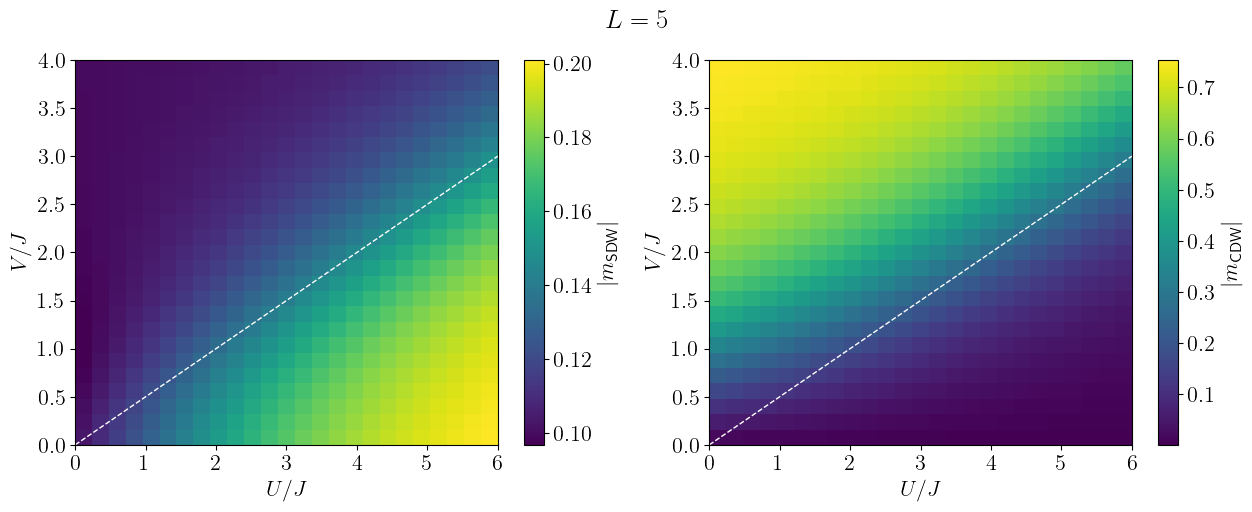

In [62]:
U_min_plot, U_max_plot = 0 , U_max
V_min_plot, V_max_plot = 0 , V_max

def select_region(U_vals, V_vals, data, U_min_plot, U_max_plot, V_min_plot, V_max_plot):
    U_mask = (U_vals >= U_min_plot) & (U_vals <= U_max_plot)
    V_mask = (V_vals >= V_min_plot) & (V_vals <= V_max_plot)
    return U_vals[U_mask], V_vals[V_mask], data[np.ix_(V_mask, U_mask)]

# Slice arrays
U_vals_plot, V_vals_plot, m_sdw_plot = select_region(U_vals, V_vals, m_sdw, U_min_plot, U_max_plot, V_min_plot, V_max_plot)
_, _, m_cdw_plot = select_region(U_vals, V_vals, m_cdw, U_min_plot, U_max_plot, V_min_plot, V_max_plot)

# Meshgrid for contours
X, Y = np.meshgrid(U_vals_plot, V_vals_plot)

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
plt.suptitle(f"$L = {L}$")

# m_SDW
im0 = ax[0].imshow(m_sdw_plot, origin="lower", extent=[U_min_plot, U_max_plot, V_min_plot, V_max_plot], aspect="auto", cmap=theme)
fig.colorbar(im0, ax=ax[0], label=r"$|m_{\text{SDW}}|$")
# ax[0].contour(X, Y, np.abs(m_sdw_plot), colors='white', linestyle='--', linewidths=0.7)
ax[0].set_xlabel(r"$U / J$")
ax[0].set_ylabel(r"$V / J$")

# m_CDW
im1 = ax[1].imshow(m_cdw_plot, origin="lower", extent=[U_min_plot, U_max_plot, V_min_plot, V_max_plot], aspect="auto", cmap=theme)
fig.colorbar(im1, ax=ax[1], label=r"$|m_{\text{CDW}}|$")
# ax[1].contour(X, Y, np.abs(m_cdw_plot), colors='white', linestyle='--', linewidths=0.7)
ax[1].set_xlabel(r"$U / J$")
ax[1].set_ylabel(r"$V / J$")

# Line U = 2V
V_range = np.linspace(max(0, V_min_plot), min(U_max_plot / 2, V_max_plot), N_Points)
U_range = 2 * V_range
ax[0].plot(U_range, V_range, 'w--', linewidth=1)
ax[1].plot(U_range, V_range, 'w--', linewidth=1)

# Save and show
plt.savefig(f"{figures_path}/{model}_{exec}/order_parameters_L={L}_U={U_min_plot}-{U_max_plot}_V={V_min_plot}-{V_max_plot}.png", dpi=300, bbox_inches="tight")
plt.show()

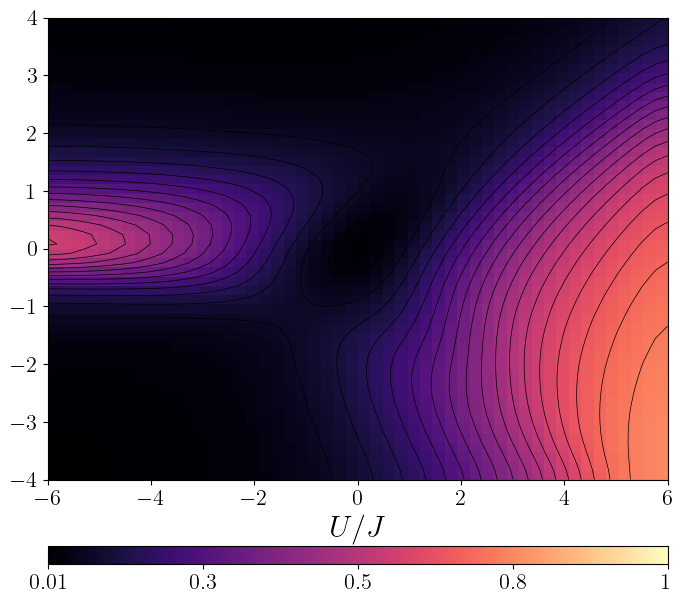

In [106]:
def plot_phase_diagram(measure, U_vals, V_vals, x_label, y_label, measure_label, fname, 
                       x_min=0.0, y_min=0.0, theme="viridis", num_ticks=5, upper_bound=None):

    fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

    sigma_smoothing = 1.5
    num_contour_levels = 20

    U_min = x_min
    U_max = np.max(U_vals)
    V_min = y_min
    V_max = np.max(V_vals)

    # Masks
    mask_U = (U_vals >= U_min) & (U_vals <= U_max)
    U_vals_new = U_vals[mask_U]

    mask_V = (V_vals >= V_min) & (V_vals <= V_max)
    V_vals_new = V_vals[mask_V]

    # Apply masks
    masked_measure = measure[mask_V, :]
    masked_measure = masked_measure[:, mask_U]
    smoothed_measure = gaussian_filter(masked_measure, sigma=sigma_smoothing)

    X, Y = np.meshgrid(U_vals_new, V_vals_new)

    # Normalization
    vmin = np.min(smoothed_measure)
    vmax = np.max(smoothed_measure) if upper_bound is None else upper_bound
    norm = Normalize(vmin=vmin, vmax=vmax)

    im0 = ax1.imshow(smoothed_measure, origin="lower", extent=[U_min, U_max, V_min, V_max],
                     aspect="auto", cmap=theme, norm=norm)
    
    # ---- COLORBAR ON TOP ----
    pos = ax1.get_position()
    cax = fig.add_axes([pos.x0, -0.03, pos.width, 0.03]) # [left, bottom, width, height]
    cbar = fig.colorbar(im0, cax=cax, orientation="horizontal")

    # Fixed ticks evenly spaced between vmin and vmax/upper_bound
    ticks = np.linspace(vmin, vmax, num_ticks)
    cbar.set_ticks(ticks)

    # Put ticks on top
    cbar.ax.xaxis.set_ticks_position("bottom")
    cbar.ax.xaxis.set_label_position("bottom")

    # Format: one significant digit in LaTeX
    cbar.ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:.1g}$"))

    # Optional: add label
    # cbar.set_label(measure_label, labelpad=5)

    # Contours
    ax1.contour(X, Y, smoothed_measure, levels=num_contour_levels, colors='black', linewidths=0.5)
    ax1.set_xlabel(x_label, fontsize = 22)
    # ax1.set_ylabel(y_label)

    fig.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()

plot_phase_diagram(Q_2, U_vals, V_vals, 
                    r"$U/J$", r"$V/J$", r"$Q_2$", 
                    fig_path.replace("XXXXX", f"Q_2_smoothed_L={L}_NPoints={N_Points}.png"),
                    np.min(U_vals), np.min(V_vals), theme = "magma", upper_bound=1.0)

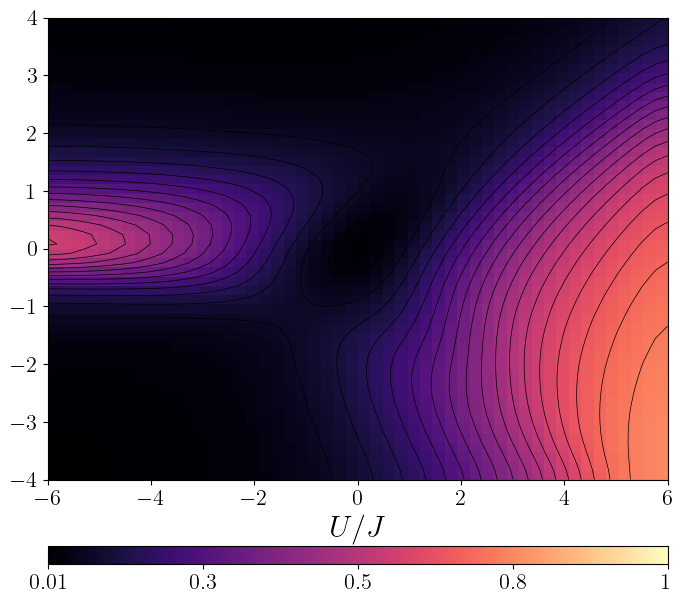

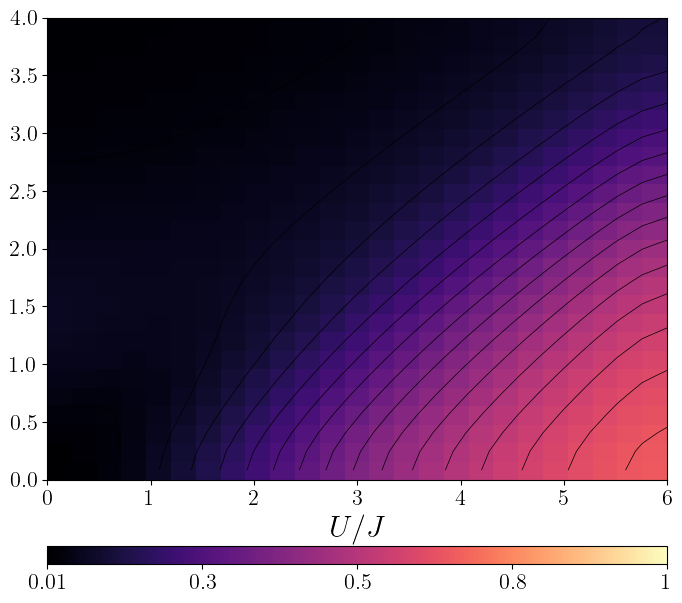

In [107]:
plot_phase_diagram(Q_2, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$Q_2$", 
                   fig_path.replace("XXXXX", f"Q_2_smoothed_L={L}_NPoints={N_Points}.png"),
                   np.min(U_vals), np.min(V_vals), theme = "magma", upper_bound=1.0)

plot_phase_diagram(Q_2, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$Q_2$", 
                   fig_path.replace("XXXXX", f"Q_2_smoothed_L={L}_NPoints={N_Points}_mask.png"),
                   0.0, 0.0, theme = "magma", upper_bound=1.0)

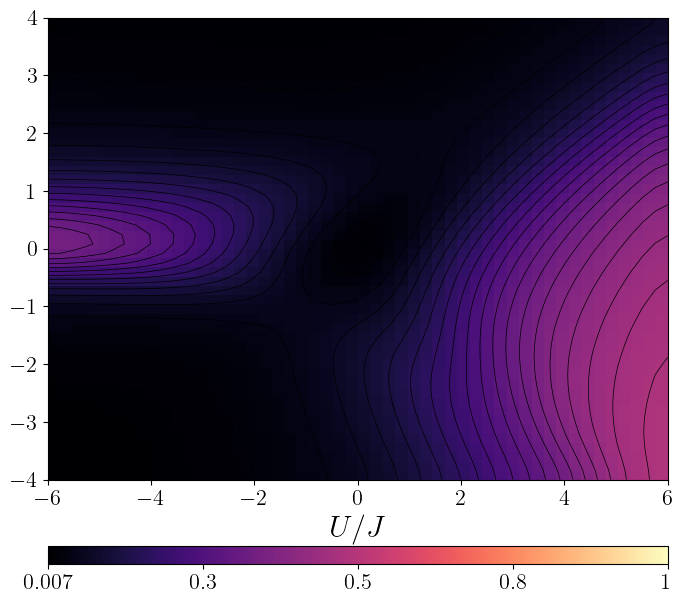

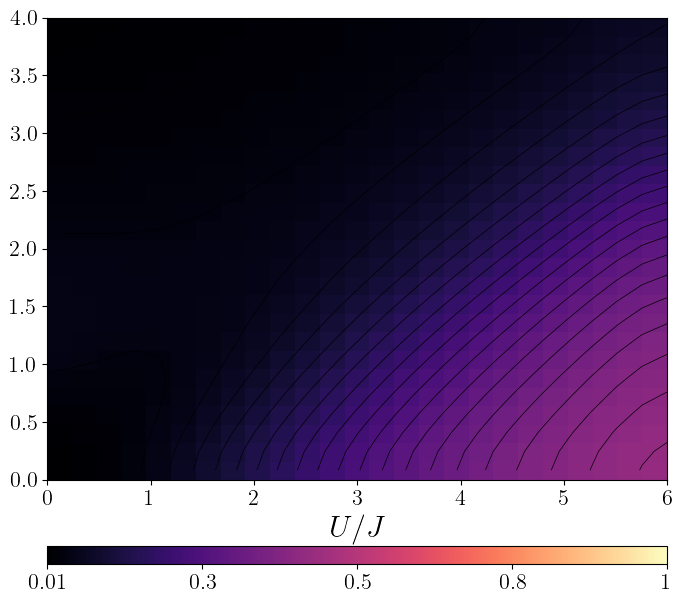

In [108]:
plot_phase_diagram(E_p, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$E_p$", 
                   fig_path.replace("XXXXX", f"E_p_smoothed_L={L}_NPoints={N_Points}.png"),
                   np.min(U_vals), np.min(V_vals), theme = "magma", upper_bound=1.0)

plot_phase_diagram(E_p, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$E_p$", 
                   fig_path.replace("XXXXX", f"E_p_smoothed_L={L}_NPoints={N_Points}_mask.png"),
                   0.0, 0.0, theme = "magma", upper_bound=1.0)

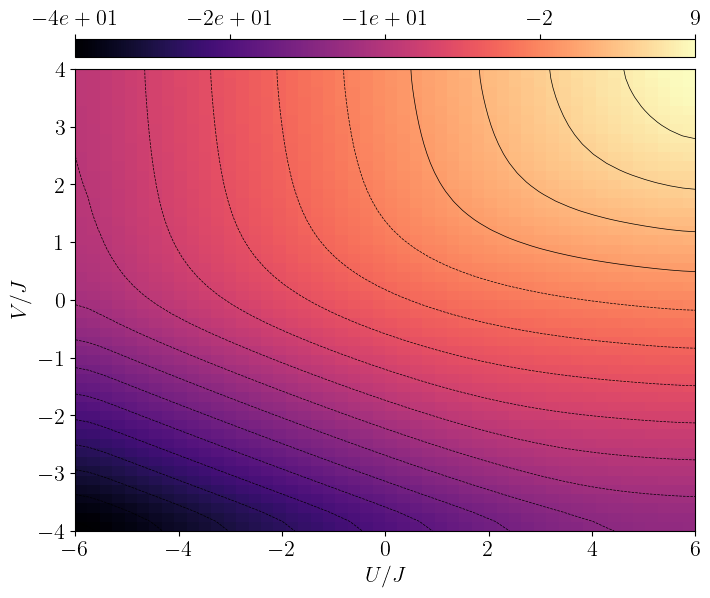

In [66]:
plot_phase_diagram(E_GS, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$E_\text{GS}$", 
                   fig_path.replace("XXXXX", f"E_GS_smoothed_L={L}_NPoints={N_Points}.png"),
                   np.min(U_vals), np.min(V_vals), theme = "magma")

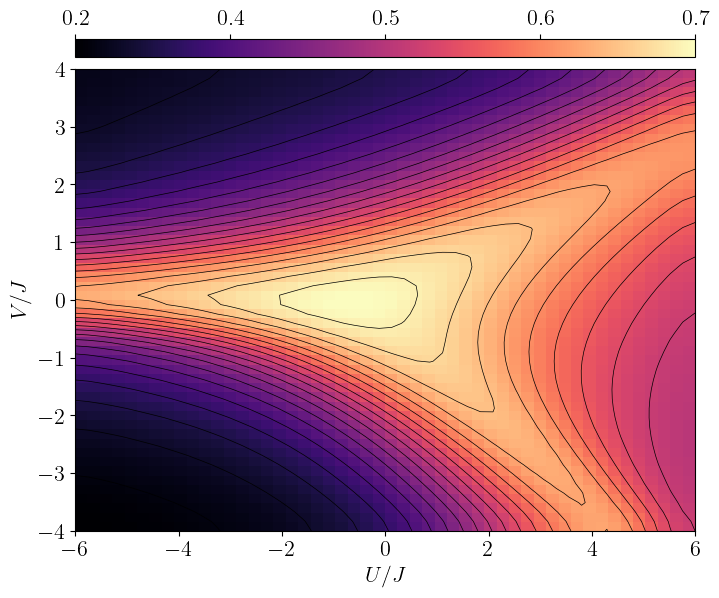

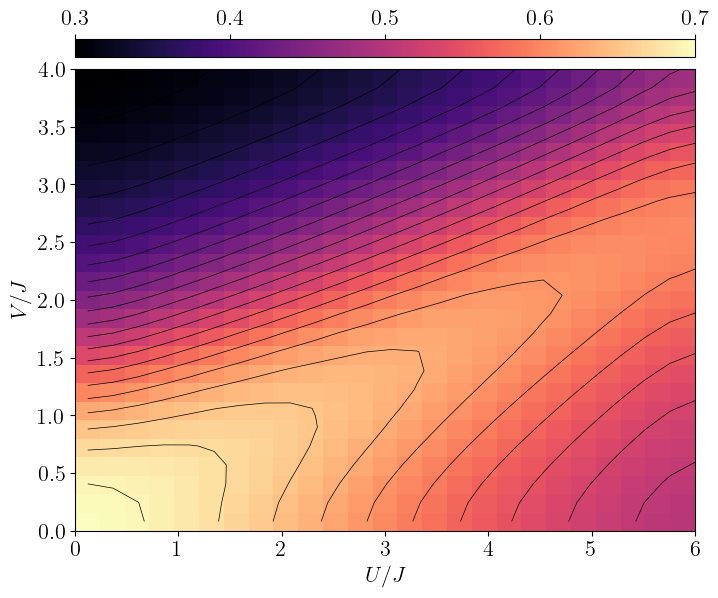

In [67]:
plot_phase_diagram(quantum_coherence_1, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$C_{\ell_1}(\hat{\rho}_1)$", 
                   fig_path.replace("XXXXX", f"quantum_coherence_1rdm_smoothed_L={L}_NPoints={N_Points}.png"),
                   np.min(U_vals), np.min(V_vals), theme = "magma")

plot_phase_diagram(quantum_coherence_1, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$C_{\ell_1}(\hat{\rho}_1)$", 
                   fig_path.replace("XXXXX", f"quantum_coherence_1rdm_smoothed_L={L}_NPoints={N_Points}_mask.png"),
                   0.0, 0.0, theme = "magma")

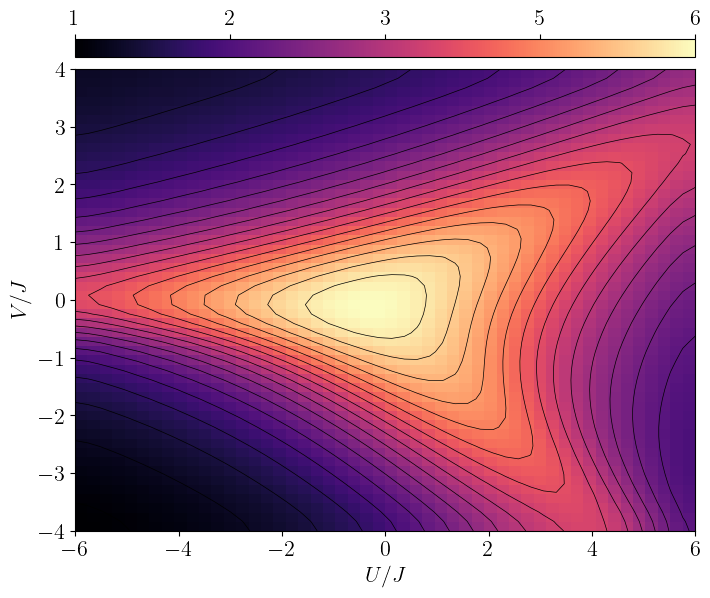

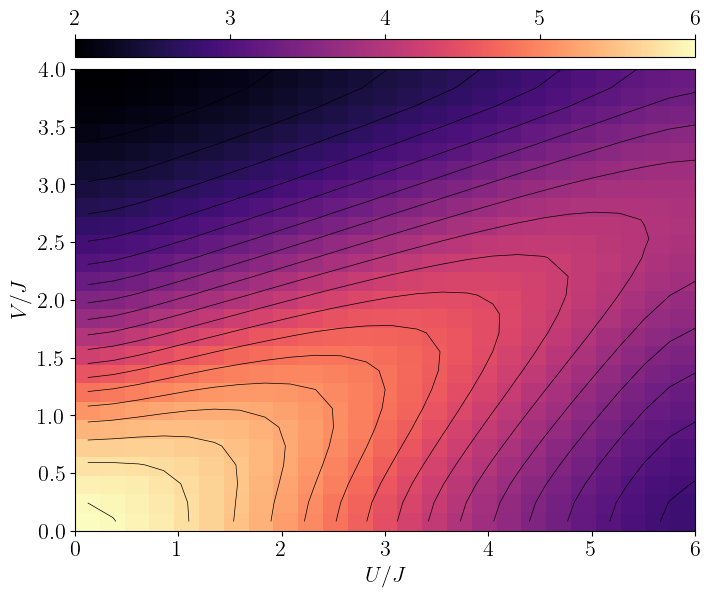

In [68]:

plot_phase_diagram(quantum_coherence_2, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$C_{\ell_1}(\hat{\rho}_2)$", 
                   fig_path.replace("XXXXX", f"quantum_coherence_2rdm_smoothed_L={L}_NPoints={N_Points}.png"),
                   np.min(U_vals), np.min(V_vals), theme = "magma")
plot_phase_diagram(quantum_coherence_2, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$C_{\ell_1}(\hat{\rho}_2)$", 
                   fig_path.replace("XXXXX", f"quantum_coherence_2rdm_smoothed_L={L}_NPoints={N_Points}_mask.png"),
                   0.0, 0.0, theme = "magma")

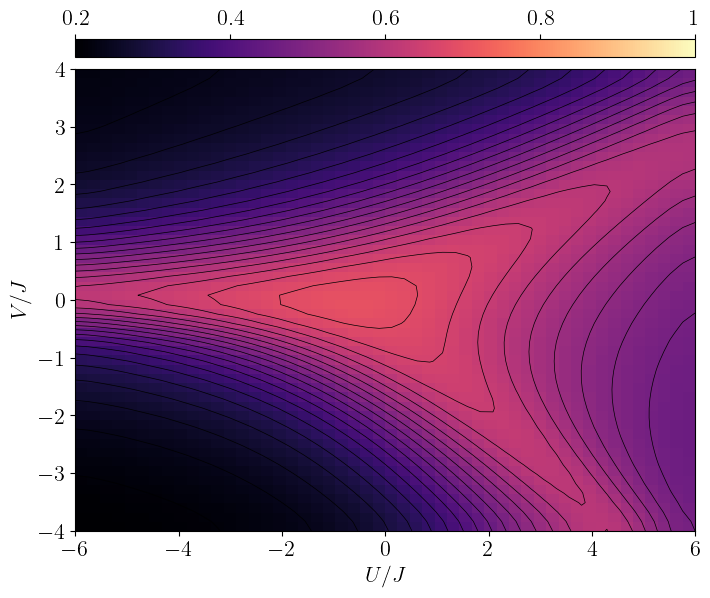

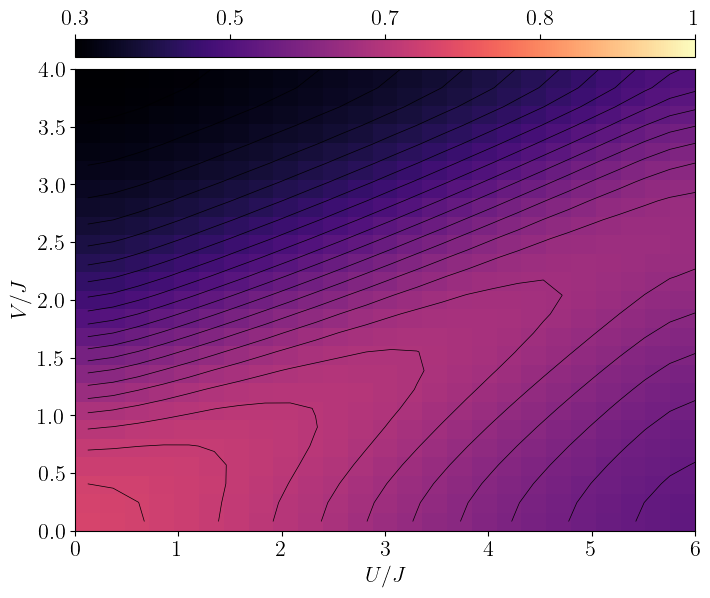

In [69]:
plot_phase_diagram(avg_linear_entropy, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$\bar{\mathcal{L}}$", 
                   fig_path.replace("XXXXX", f"avg_single_site_entanglement_smoothed_L={L}_NPoints={N_Points}.png"),
                   np.min(U_vals), np.min(V_vals), theme = "magma", upper_bound=1.0)

plot_phase_diagram(avg_linear_entropy, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$\bar{\mathcal{L}}$", 
                   fig_path.replace("XXXXX", f"avg_single_site_entanglement_smoothed_L={L}_NPoints={N_Points}.png"),
                   0.0, 0.0, theme = "magma", upper_bound=1.0)

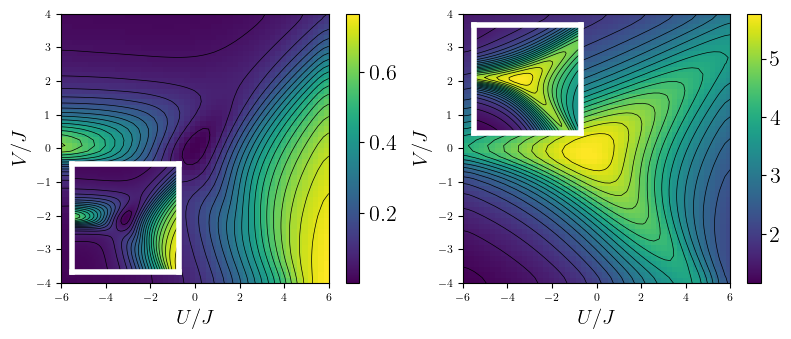

In [70]:
# --- parameters ---
sigma_smoothing    = 1.5
num_contour_levels = 20

# precompute extents & mesh
U_min, U_max = U_vals.min(), U_vals.max()
V_min, V_max = V_vals.min(), V_vals.max()
X, Y = np.meshgrid(U_vals, V_vals)

# helper to draw an imshow+contour
def draw_map(ax, data):
    sm = gaussian_filter(data, sigma=sigma_smoothing)
    im = ax.imshow(data, origin="lower",
                   extent=[U_min, U_max, V_min, V_max],
                   aspect="auto", cmap=theme)
    ax.contour(X, Y, sm, levels=num_contour_levels, colors='k', linewidths=0.5)
    ax.set_xlabel(r"$U/J$", fontsize=15)
    ax.set_ylabel(r"$V/J$", fontsize=15)
    ax.tick_params(labelsize=8)
    return im

# --- figure setup ---
fig, (axQ2, axC2) = plt.subplots(1, 2, figsize=(9.5, 3.5))

# main 1: Q2
imQ2 = draw_map(axQ2, Q_2)
fig.colorbar(imQ2, ax=axQ2, orientation='vertical') # , label=r"$Q_2$")

# inset for E_p
axins1 = inset_axes(axQ2, width="40%", height="40%", loc="lower left")

# give the inset a white background and white border
axins1.set_facecolor("white")
for spine in axins1.spines.values():
    spine.set_edgecolor("white")
    spine.set_linewidth(4)

draw_map(axins1, E_p)  # no title on inset
axins1.set_xticks([])
axins1.set_yticks([])

axins1.set_xlabel("")
axins1.set_ylabel("")

# main 2: C_l1(rho2)
imC2 = draw_map(axC2, quantum_coherence_2)
fig.colorbar(imC2, ax=axC2, orientation='vertical') # , label=r"$Q_2$")

# inset for C_l1(rho1)
axins2 = inset_axes(axC2, width="40%", height="40%", loc="upper left")

# same white frame on second inset
axins2.set_facecolor("white")
for spine in axins2.spines.values():
    spine.set_edgecolor("white")
    spine.set_linewidth(4)

draw_map(axins2, quantum_coherence_1)
axins2.set_xticks([])
axins2.set_yticks([])
axins2.set_xlabel("")
axins2.set_ylabel("")
# save & show
plt.savefig(f"{figures_path}/{model}_{exec}/big_Q2_C2_with_insets_L={L}.png", dpi=300, bbox_inches="tight")
plt.show()